# Day 3 — Building the KPIs

`3.0-aroa-journey-patterns.ipynb` settled six reconstruction rules by reading
real visits. This notebook applies them to the whole dataset and turns the
event log into the measures the experiment will be judged on.

Every team computes the same KPIs. What differs is the implementation, so each
one below states how it is computed, which observations it includes, and what
it assumes.

The rules being applied:

1. A visit is one journey; its first `start` opens it
2. The first `confirm` closes it
3. The client is the unit of analysis; the visit is reported alongside
4. Completing means reaching `confirm` — for a client, in any visit
5. Visits with no measurable duration count in rates, not in times
6. Backward movement is measured, not assumed to be an error

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from project_template.paths import PROCESSED_DIR
from project_template.config import CONFIG

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

MAROON, NAVY, GREY = "#96151D", "#21384E", "#857B7E"
PALETTE = {"Control": NAVY, "Test": MAROON}

FUNNEL = CONFIG["funnel"]
STEP_ORDER = {step: i for i, step in enumerate(FUNNEL)}
CONFIRM_RANK = STEP_ORDER["confirm"]

events = pd.read_parquet(PROCESSED_DIR / "events.parquet")
clients = pd.read_parquet(PROCESSED_DIR / "clients.parquet")

events = events.sort_values(["visit_id", "date_time"]).reset_index(drop=True)
print(f"{len(events):,} events   {events.visit_id.nunique():,} visits   "
      f"{events.client_id.nunique():,} clients")

317,135 events   69,185 visits   50,488 clients


## Rule 1 and 2 — Trimming each journey

A journey runs from a visit's first `start` to its first `confirm`. Events
before the opening `start` or after the closing `confirm` fall outside the
attempt we are measuring, so they are excluded from the timing measures while
the visit itself stays in the rates.

In [2]:
first_start = (
    events[events.process_step == "start"]
    .groupby("visit_id").date_time.min().rename("opened_at")
)
first_confirm = (
    events[events.process_step == "confirm"]
    .groupby("visit_id").date_time.min().rename("closed_at")
)

events = events.merge(first_start, on="visit_id", how="left")
events = events.merge(first_confirm, on="visit_id", how="left")

# Inside the attempt: at or after the opening start, at or before the first confirm
events["in_journey"] = (
    (events.opened_at.notna())
    & (events.date_time >= events.opened_at)
    & (events.date_time <= events.closed_at.fillna(events.date_time.max()))
)

print(f"events inside a journey: {events.in_journey.sum():,} "
      f"({events.in_journey.mean():.1%})")
print(f"events outside:          {(~events.in_journey).sum():,}")

events inside a journey: 300,982 (94.9%)
events outside:          16,153


## Journey-level measures

Everything is computed per visit first, then aggregated to the client. Both
levels are kept: the client level answers the experiment's question, the visit
level describes a single session.

In [3]:
inside = events[events.in_journey].copy()

# Time between consecutive events, and whether the step advanced
inside["gap_s"] = inside.groupby("visit_id").date_time.diff().dt.total_seconds()
inside["advanced"] = inside.step_rank.diff() > 0
inside.loc[inside.groupby("visit_id").cumcount() == 0, "advanced"] = False

by_visit = inside.groupby("visit_id")

journeys = pd.DataFrame({
    "client_id": by_visit.client_id.first(),
    "group": by_visit.Variation.first(),
    "events": by_visit.size(),
    "max_step": by_visit.step_rank.max(),
    "opened_at": by_visit.date_time.min(),
    "step_backs": by_visit.is_backward.sum(),
    "repeated_steps": by_visit.is_repeat.sum(),
})

journeys["completed"] = journeys.max_step == CONFIRM_RANK

# Rule 5: durations only where there is something to measure
duration = (by_visit.date_time.max() - by_visit.date_time.min()).dt.total_seconds()
journeys["completion_time_s"] = np.where(
    journeys.completed & (duration > 0), duration, np.nan
)

# Effective time: only the intervals in which the client moved forward
forward = inside[inside.advanced].groupby("visit_id").gap_s.sum()
journeys["effective_time_s"] = journeys.index.map(forward).where(journeys.completed)

print(f"{len(journeys):,} journeys   {journeys.completed.sum():,} completed "
      f"({journeys.completed.mean():.1%})")
journeys.head()

63,885 journeys   32,658 completed (51.1%)


,client_id,group,events,max_step,opened_at,step_backs,repeated_steps,completed,completion_time_s,effective_time_s
visit_id,,,,,,,,,,
100019538_17884295066_43909,7338123,Test,11,4,2017-04-09 16:20:56,2,2,True,242.0,204.0
100022086_87870757897_149620,2478628,Test,5,4,2017-05-23 20:44:01,0,0,True,180.0,180.0
100030127_47967100085_936361,105007,Control,1,0,2017-03-22 11:07:49,0,0,False,NaN,NaN
100037962_47432393712_705583,5623007,Control,4,1,2017-04-14 16:41:51,1,1,False,NaN,NaN
100057941_88477660212_944512,4823947,Control,7,3,2017-04-09 11:30:10,1,0,False,NaN,NaN


## KPI 1 — Completion Rate

**How it is computed.** A client completed if any of their journeys reached
`confirm`. The denominator is every client with at least one recorded journey.

**What it includes.** All journeys, including single-event visits: leaving
immediately is a real outcome, not missing data.

**What it assumes.** That a later success is not undone by an earlier failed
attempt, which is what the business cares about.

In [4]:
by_client = journeys.groupby("client_id")

kpis = pd.DataFrame({
    "group": by_client.group.first(),
    "journeys": by_client.size(),
    "completed_journeys": by_client.completed.sum(),
    "completed": by_client.completed.any(),
    "furthest_step": by_client.max_step.max(),
    "step_backs": by_client.step_backs.sum(),
    "repeated_steps": by_client.repeated_steps.sum(),
})

completion = kpis.groupby("group").completed.agg(["sum", "count", "mean"])
completion.columns = ["completed", "clients", "rate"]
completion["rate"] = (completion["rate"] * 100).round(2)
completion

,completed,clients,rate
group,,,
Control,14796,23286,63.54
Test,17788,26572,66.94


In [5]:
per_journey = journeys.groupby("group").completed.mean().mul(100).round(2)

pd.DataFrame({
    "per client (primary)": completion["rate"],
    "per journey (secondary)": per_journey,
})

,per client (primary),per journey (secondary)
group,,
Control,63.54,48.10
Test,66.94,53.94


## KPI 2 — Funnel Conversion

**How it is computed.** For each step, the share of clients who reached it,
taken over the clients who reached the previous step. A client counts as
reaching a step if any journey got that far.

**What it assumes.** That progress is monotonic at client level — reaching
step 3 means step 2 was reached at some point, which the funnel's design
guarantees.

In [6]:
funnel = []

for step, rank in STEP_ORDER.items():
    reached = kpis.furthest_step >= rank
    for group in ["Control", "Test"]:
        in_group = kpis.group == group
        funnel.append({
            "step": step,
            "group": group,
            "clients": int((reached & in_group).sum()),
        })

funnel = pd.DataFrame(funnel).pivot(index="step", columns="group", values="clients")
funnel = funnel.reindex(FUNNEL)

for group in ["Control", "Test"]:
    funnel[f"{group} %"] = (funnel[group] / funnel[group].iloc[0] * 100).round(1)
    funnel[f"{group} step-to-step %"] = (
        funnel[group] / funnel[group].shift() * 100
    ).round(1)

funnel

group,Control,Test,Control %,Control step-to-step %,Test %,Test step-to-step %
step,,,,,,
start,23286,26572,100.0,NaN,100.0,NaN
step_1,19900,24012,85.5,85.5,90.4,90.4
step_2,18320,21869,78.7,92.1,82.3,91.1
step_3,16934,20271,72.7,92.4,76.3,92.7
confirm,14796,17788,63.5,87.4,66.9,87.8


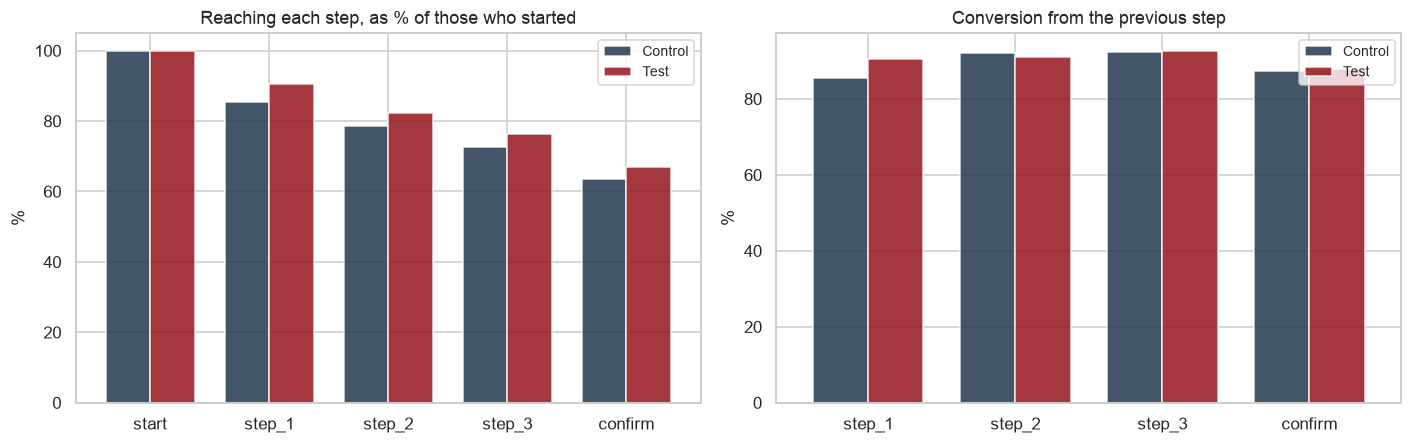

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

share = funnel[["Control %", "Test %"]]
share.plot(kind="bar", ax=axes[0], color=[NAVY, MAROON], alpha=.85, width=.75)
axes[0].set_title("Reaching each step, as % of those who started", fontsize=11.5)
axes[0].set_xlabel(""); axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Control", "Test"], fontsize=9)

step_to_step = funnel[["Control step-to-step %", "Test step-to-step %"]].iloc[1:]
step_to_step.plot(kind="bar", ax=axes[1], color=[NAVY, MAROON], alpha=.85, width=.75)
axes[1].set_title("Conversion from the previous step", fontsize=11.5)
axes[1].set_xlabel(""); axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Control", "Test"], fontsize=9)

fig.tight_layout()
plt.show()

## KPI 3 — Completion Time

**How it is computed.** For a completed journey, the seconds from its opening
`start` to its first `confirm`. At client level we take the client's **first
completed journey**, since that is the attempt that succeeded.

**What it includes.** Only completed journeys with a measurable duration.
Abandoned journeys have no completion to time, and zero-duration journeys have
nothing to measure.

**What it assumes.** That elapsed time within a session approximates the
effort the process demanded — an assumption that weakens if a client walked
away mid-session, which is what the next KPI addresses.

In [8]:
completed = journeys[journeys.completed & journeys.completion_time_s.notna()]
first_completion = completed.sort_values("opened_at").groupby("client_id").first()

kpis["completion_time_s"] = first_completion.completion_time_s
kpis["effective_time_s"] = first_completion.effective_time_s

times = kpis.groupby("group").completion_time_s.describe()[
    ["count", "25%", "50%", "75%", "max"]
].round(1)
times

,count,25%,50%,75%,max
group,,,,,
Control,14796.0,173.0,272.0,454.2,17072.0
Test,17788.0,148.0,238.0,423.0,18015.0


## KPI 4 — Effective Time

**How it is computed.** Within a completed journey, the sum of the intervals
in which the client moved **forward** through the funnel. Time spent
repeating a step or going back is excluded, as is any pause that did not end
in progress.

**Why it differs from Completion Time.** Completion Time measures how long the
process took; Effective Time approximates how much of that was spent making
progress. The gap between them is hesitation, review and interruption.

In [9]:
overview = kpis.groupby("group")[["completion_time_s", "effective_time_s"]].median()
overview["difference"] = overview.completion_time_s - overview.effective_time_s
overview["% of time spent progressing"] = (
    overview.effective_time_s / overview.completion_time_s * 100
).round(1)
overview.round(1)

,completion_time_s,effective_time_s,difference,% of time spent progressing
group,,,,
Control,272.0,239.0,33.0,87.9
Test,238.0,201.0,37.0,84.5


## KPI 5 — Error Rate, under two definitions

Rule 6 held that backward movement is ambiguous. Rather than choosing one
reading and hiding the choice, both are computed:

- **Definition A — repeated steps.** A client redoing the same step suggests
  something did not take. This is our primary definition.
- **Definition B — backward moves.** The stricter reading, in which any return
  to an earlier step counts as an error.

If the conclusion is the same under both, it does not rest on this choice. If
it differs, that is the finding, and it has to be reported as such.

In [10]:
kpis["error_rate_a"] = kpis.repeated_steps / kpis.journeys   # repeated steps
kpis["error_rate_b"] = kpis.step_backs / kpis.journeys       # backward moves

errors = kpis.groupby("group")[["error_rate_a", "error_rate_b"]].mean().round(4)
errors.columns = ["A — repeated steps per journey", "B — backward moves per journey"]
errors

,A — repeated steps per journey,B — backward moves per journey
group,,
Control,0.3336,0.2886
Test,0.4225,0.4473


## KPI 6 — Step Backs

**How it is computed.** Backward movements per journey, averaged over a
client's journeys. Reported on its own rather than folded into Error Rate, so
that navigation behaviour can be described without asserting what it means.

In [11]:
kpis["step_backs_per_journey"] = kpis.step_backs / kpis.journeys

steps = kpis.groupby("group").step_backs_per_journey.agg(["mean", "median"]).round(3)
steps["clients with any step back"] = (
    kpis[kpis.step_backs > 0].groupby("group").size()
)
steps

,mean,median,clients with any step back
group,,,
Control,0.289,0.0,5600
Test,0.447,0.0,8738


## KPI 7 — Abandonment Rate (optional)

**How it is computed.** The share of clients who started the process but never
reached `confirm` in any journey. It is the complement of Completion Rate at
client level, reported separately because it is the framing a stakeholder
usually asks for.

In [12]:
kpis["abandoned"] = ~kpis.completed

abandonment = kpis.groupby("group").abandoned.mean().mul(100).round(2)
abandonment.to_frame("abandonment rate %")

,abandonment rate %
group,
Control,36.46
Test,33.06


## Validating the KPIs

Before any of this goes into a statistical test, check that the measures
behave sensibly: look at their distributions, and investigate anything
unexpected.

In [13]:
NUMERIC_KPIS = ["completion_time_s", "effective_time_s",
                "error_rate_a", "error_rate_b", "step_backs_per_journey"]

kpis[NUMERIC_KPIS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
completion_time_s,32584.0,383.78,445.03,33.0,159.0,255.0,438.0,18015.0
effective_time_s,32584.0,291.81,242.82,13.0,144.0,218.0,348.0,4548.0
error_rate_a,49858.0,0.38,0.83,0.0,0.0,0.0,0.5,14.0
error_rate_b,49858.0,0.37,0.79,0.0,0.0,0.0,0.5,25.0
step_backs_per_journey,49858.0,0.37,0.79,0.0,0.0,0.0,0.5,25.0


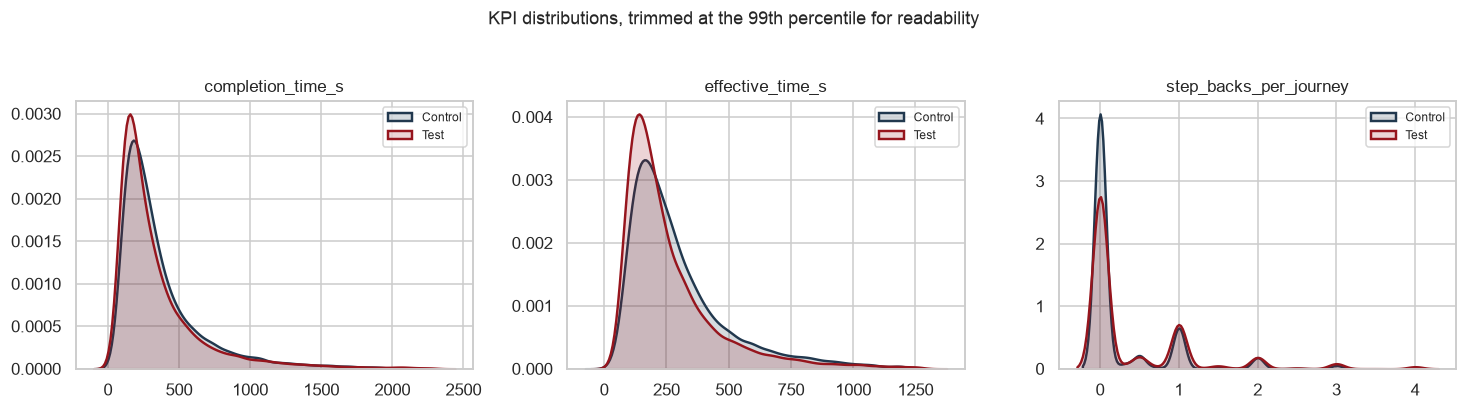

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))

for ax, col in zip(axes, ["completion_time_s", "effective_time_s",
                          "step_backs_per_journey"]):
    for group, colour in PALETTE.items():
        data = kpis.loc[kpis.group == group, col].dropna()
        upper = data.quantile(.99)
        sns.kdeplot(data[data <= upper], ax=ax, label=group,
                    color=colour, fill=True, alpha=.18, linewidth=1.6)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=8)

fig.suptitle("KPI distributions, trimmed at the 99th percentile for readability",
             fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

### Anything unexpected?

In [15]:
checks = {
    "clients with no journeys": (kpis.journeys == 0).sum(),
    "completed but no completion time": int(
        (kpis.completed & kpis.completion_time_s.isna()).sum()
    ),
    "effective time longer than completion time": int(
        (kpis.effective_time_s > kpis.completion_time_s).sum()
    ),
    "negative durations": int((kpis.completion_time_s < 0).sum()),
    "completion time over one hour": int((kpis.completion_time_s > 3600).sum()),
}

for label, n in checks.items():
    print(f"{label:46} {n:>7,}")

print()
print(f"longest completion time: {kpis.completion_time_s.max():,.0f}s "
      f"({kpis.completion_time_s.max() / 60:.0f} min)")

clients with no journeys                             0
completed but no completion time                     0
effective time longer than completion time           0
negative durations                                   0
completion time over one hour                       60

longest completion time: 18,015s (300 min)


Clients who completed but carry no completion time are the ones whose only
successful journey finished in the same second it began — Rule 5 excludes them
from timing while keeping them in the rates, which is why the two counts
differ.

## The analysis dataset

One row per client, carrying the KPIs, the experimental group and the
demographics day 2 profiled. This is what the statistical comparison on day 4
and the Tableau dashboard both read.

In [16]:
analysis = kpis.reset_index().merge(
    clients.drop(columns=["Variation"]), on="client_id", how="left"
)

analysis["age_band"] = pd.cut(
    analysis.clnt_age, [0, 35, 50, 65, 120],
    labels=["<35", "35-50", "50-65", "65+"],
)

print(f"{len(analysis):,} clients x {analysis.shape[1]} columns")
print()
print(list(analysis.columns))
analysis.head()

49,858 clients x 23 columns

['client_id', 'group', 'journeys', 'completed_journeys', 'completed', 'furthest_step', 'step_backs', 'repeated_steps', 'completion_time_s', 'effective_time_s', 'error_rate_a', 'error_rate_b', 'step_backs_per_journey', 'abandoned', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'age_band']


,client_id,group,journeys,completed_journeys,completed,furthest_step,step_backs,repeated_steps,completion_time_s,effective_time_s,error_rate_a,error_rate_b,step_backs_per_journey,abandoned,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_band
0,555,Test,1,1,True,4,0,0,158.0,158.0,0.0,0.0,0.0,False,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,<35
1,647,Test,1,1,True,4,0,0,377.0,377.0,0.0,0.0,0.0,False,12.0,151.0,57.5,M,2.0,30525.80,0.0,4.0,50-65
2,934,Test,1,0,False,0,0,3,NaN,NaN,3.0,0.0,0.0,True,9.0,109.0,51.0,F,2.0,32522.88,0.0,3.0,50-65
3,1028,Control,1,0,False,3,2,2,NaN,NaN,2.0,2.0,2.0,True,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,35-50
4,1104,Control,2,0,False,0,0,0,NaN,NaN,0.0,0.0,0.0,True,5.0,66.0,48.0,U,3.0,154643.94,6.0,9.0,35-50


In [17]:
analysis.to_parquet(PROCESSED_DIR / "client_kpis.parquet", index=False)
journeys.reset_index().to_parquet(PROCESSED_DIR / "journeys.parquet", index=False)

# Tableau reads CSV more comfortably than parquet
analysis.to_csv(PROCESSED_DIR / "client_kpis.csv", index=False)

for f in sorted(PROCESSED_DIR.glob("*")):
    if f.suffix in {".parquet", ".csv"}:
        print(f"{f.name:24} {f.stat().st_size / 1024**2:6.1f} MB")

client_kpis.csv             4.8 MB
client_kpis.parquet         1.2 MB
clients.parquet             0.9 MB
events.parquet              6.9 MB
journeys.parquet            2.6 MB


## Summary

| KPI | Unit | Included | Excluded |
|---|---|---|---|
| Completion Rate | client | every client with a journey | — |
| Funnel Conversion | client | every client with a journey | — |
| Completion Time | client | first completed journey, with duration > 0 | abandoned and zero-duration journeys |
| Effective Time | client | forward intervals of that same journey | pauses, repeats and backward moves |
| Error Rate A | client | repeated steps per journey | — |
| Error Rate B | client | backward moves per journey | — |
| Step Backs | client | backward moves per journey | — |
| Abandonment Rate | client | complement of Completion Rate | — |

**Limitations to carry forward.**

Completion Time measures elapsed time inside a session, so it cannot
distinguish a client who worked steadily from one who left the tab open. That
is the reason Effective Time exists alongside it, and why neither should be
read on its own.

Timing measures describe completed journeys only. A design could in principle
make completion slower while making it far more likely, and the two KPIs have
to be read together for that reason.

Error Rate depends on a definition that could reasonably have gone the other
way, which is why both are carried into day 4 rather than one.

**Final question:** are these KPIs ready to support a fair statistical
comparison between Control and Test?